In [27]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [28]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [29]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from data_handlers.CardiacUDA.datasets import SemiSupervisedDataset, UDATestDataset
from utils.file_management import serialize_config, get_version_folder
from utils.plots import show_images
from utils.augmentation import GeometricAug, NoiseAug
from model import EncoderDecoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Config

In [30]:
str(LOAD_RUN)

'acc_6927_copy'

In [31]:
# Set to a run number (e.g. 37) to resume that run, or None to start fresh
LOAD_RUN ='acc_6927_copy'

root = 'cache/model_weights/semisup'

if LOAD_RUN is not None:
    index_folder = os.path.join(root, str(LOAD_RUN))
    with open(os.path.join(index_folder, 'config.json')) as f:
        config = json.load(f)
    print(f'Loaded config from run {LOAD_RUN}:')
    config['model_path'] = os.path.join(index_folder, 'model.pt')
    config['config_path'] = os.path.join(index_folder, 'config.json')
else:
    index_folder = get_version_folder(root)
    config = {
        'lr': 1e-4,
        'epochs': 30,
        'batch_size': 32,
        # fraction of labeled training samples to use (fixed subset, chosen once by seed)
        'labeled_fraction': 0.01,
        'seed': 42,
        'bottleneck_dim': 1024,
        'number_of_vectors': 1024,
        # only these channels are trained/evaluated; every other channel merges into background
        'train_channels': [0, 3, 4],
        # single flag applied to ALL vectorizers (one vectorizer per class)
        'vectorizers_mat_mul': True,
        # loss weights
        'reconstruction_weight':30.0,
        'segmentation_weight': 1.0,
        # sites to include — None means all sites
        'sites': ['Site_G_20','Site_G_29','Site_G_100'],
        'model_path': os.path.join(index_folder, 'model.pt'),
        'config_path': os.path.join(index_folder, 'config.json'),
    }
    with open(config['config_path'], 'w') as f:
        json.dump(serialize_config(config), f, indent=2)
    print('Starting fresh run:')

# Derive the number of classes from the channels we train on.
config.setdefault('train_channels', list(range(config.get('num_classes', 5))))
config['num_classes'] = len(config['train_channels'])          # one class per kept channel
config['number_of_vectors'] = config['number_of_vectors']            # one vectorizer per class
flag = config['vectorizers_mat_mul']
if isinstance(flag, (list, tuple)):                            # tolerate old list-form configs
    flag = flag[0]
config['vectorizers_mat_mul'] = bool(flag)
config['vectorizers_mat_mul_list'] = [flag] * config['num_classes']

print(json.dumps(serialize_config(config), indent=2))

Loaded config from run acc_6927_copy:
{
  "lr": 0.0001,
  "epochs": 30,
  "batch_size": 32,
  "labeled_fraction": 0.01,
  "seed": 42,
  "bottleneck_dim": 1024,
  "number_of_vectors": 1024,
  "train_channels": [
    0,
    3,
    4
  ],
  "vectorizers_mat_mul": true,
  "reconstruction_weight": 30.0,
  "segmentation_weight": 1.0,
  "sites": [
    "Site_G_20",
    "Site_G_29",
    "Site_G_100"
  ],
  "model_path": "cache/model_weights/semisup/acc_6927_copy/model.pt",
  "config_path": "cache/model_weights/semisup/acc_6927_copy/config.json",
  "num_classes": 3,
  "vectorizers_mat_mul_list": [
    true,
    true,
    true
  ]
}


## Dataset

In [32]:
from torch.utils.data import Subset
import itertools

dataset = SemiSupervisedDataset(
    labeled_fraction=config['labeled_fraction'],
    root='../data_handlers/CardiacUDA/data/sliced_data/train',
    num_classes=config['num_classes'],
    seed=config['seed'],
    sites=config['sites'],
)

# Separate loaders so every iteration sees one batch of each
labeled_loader = torch.utils.data.DataLoader(
    Subset(dataset, dataset.labeled_indices),
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0,
)
unlabeled_loader = torch.utils.data.DataLoader(
    Subset(dataset, dataset.unlabeled_indices),
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0,
)

test_dataset = UDATestDataset(root='../data_handlers/CardiacUDA/data/test')
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

print(f'Labeled batches: {len(labeled_loader)} | Unlabeled batches: {len(unlabeled_loader)} | Test samples: {len(test_dataset)}')

SemiSupervisedDataset: 17238 total samples (7 labeled, 17231 unlabeled) | sites: ['Site_G_100', 'Site_G_20', 'Site_G_29']
Labeled batches: 1 | Unlabeled batches: 539 | Test samples: 548


## Model

In [33]:
model = EncoderDecoder(
    bottleneck_dim=config['bottleneck_dim'],
    number_of_vectors=config['number_of_vectors'],
    vectorizers_mat_mul=config['vectorizers_mat_mul_list'],
    in_channels=1,
    input_size=(256, 256),
    save_path=config['model_path'],
).to(device)

if LOAD_RUN is not None:
    model.load_state_dict(torch.load(config['model_path'], map_location=device))
    print(f'Loaded state dict from {config["model_path"]}')

optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Loaded state dict from cache/model_weights/semisup/acc_6927_copy/model.pt
Trainable parameters: 132,821,570


In [34]:
# Augmentations
# GeometricAug: same random transform applied to image AND label/reconstruction target
# NoiseAug:     corrupts the model input only — target stays clean
geo_aug   = GeometricAug(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10)
noise_aug = NoiseAug(noise_std=0.05, brightness=0.2, contrast=0.2)

## Loss functions

In [35]:
def reconstruction_loss(rec, image, seg_logits):
    """Combine per-vectorizer reconstructions into one image using the
    segmentation logits as soft masks, then compare with the original image.

    rec        : (B, N, H, W)  one reconstruction per vectorizer (already sigmoided)
    seg_logits : (B, N, H, W)  per-vectorizer segmentation logits
    image      : (B, 1, H, W)  original input image
    """
    seg_probs = F.softmax(seg_logits, dim=1)   # (B, N, H, W) soft masks over vectorizers
    combined = (seg_probs * rec).sum(dim=1)    # (B, H, W) final image
    return F.mse_loss(combined, image.squeeze(1))


def dice_loss(probs, target_onehot, eps=1e-6):
    """probs / target_onehot : (B, C, H, W)"""
    B, C = probs.shape[:2]
    p = probs.view(B, C, -1)
    t = target_onehot.view(B, C, -1)
    inter = (p * t).sum(dim=2)
    denom = p.sum(dim=2) + t.sum(dim=2)
    return (1.0 - ((2. * inter + 1e-6) / (denom + 1e-6))).mean()


def prepare_labels(labels):
    """
    Labels are already mutually exclusive:
      class 0 = background (1 = background, 0 = foreground)
      classes 1-4 = individual cardiac chambers (1 = chamber, 0 = else)
    No transformation needed — return a clone for safety.
    """
    return labels.clone()


def remap_labels(labels, train_channels):
    """Keep only the channels listed in train_channels.

    The first channel is the background: it is recomputed as the complement of
    the union of all other kept channels, so every channel NOT in train_channels
    (e.g. channels 1 and 2 when train_channels = [0, 3, 4]) becomes part of the
    background.

    labels         : (B, C, H, W) binary one-hot
    train_channels : original channel indices to keep, e.g. [0, 3, 4]
    Returns        : (B, len(train_channels), H, W) binary one-hot
    """
    nc = len(train_channels)
    new = torch.zeros(labels.shape[0], nc, *labels.shape[2:],
                     dtype=labels.dtype, device=labels.device)
    for i, c in enumerate(train_channels):
        if i > 0:
            new[:, i] = labels[:, c]
    new[:, 0] = 1.0 - new[:, 1:].sum(dim=1).clamp(0, 1)
    return new


def segmentation_loss(seg_logits, labels):
    """CE (foreground only) + Dice over all kept channels."""
    labels = prepare_labels(labels)                                    # (B, 5, H, W)
    target = labels.argmax(dim=1).long()                               # (B, H, W)
    target_oh = F.one_hot(target, num_classes=seg_logits.shape[1])     # (B, H, W, 5)
    target_oh = target_oh.permute(0, 3, 1, 2).float()                 # (B, 5, H, W)

    # CE on foreground pixels only — flatten spatial dims so mask applies cleanly
    fg_mask = labels[:, 1:].sum(dim=1).bool()                         # (B, H, W)
    logits_flat = seg_logits.permute(0, 2, 3, 1).reshape(-1, seg_logits.shape[1])  # (B*H*W, 5)
    target_flat = target.reshape(-1)                                   # (B*H*W,)
    fg_flat     = fg_mask.reshape(-1)                                  # (B*H*W,)
    ce = F.cross_entropy(logits_flat[fg_flat], target_flat[fg_flat])

    # Dice over chambers 1-4 only
    probs = F.softmax(seg_logits, dim=1)
    dl = dice_loss(probs, target_oh)

    return ce + dl

In [36]:
def evaluate():
    model.eval()
    class_dice = torch.zeros(config['num_classes'])
    n_batches  = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader, desc='Evaluating'):
            image = image.to(device)

            # Keep only the configured channels; every other channel becomes background.
            # (Test labels use channel 0 = whole-heart union; it is only kept when 0 is
            #  listed in train_channels.)
            target = remap_labels(label.float(), config['train_channels']).argmax(dim=1).cpu()

            _, seg = model(image)
            pred = seg.argmax(dim=1).cpu()                         # (B, H, W)

            for c in range(config['num_classes']):
                p = (pred   == c).float().reshape(pred.shape[0],   -1)
                t = (target == c).float().reshape(target.shape[0], -1)
                inter = (p * t).sum(dim=1)
                denom = p.sum(dim=1) + t.sum(dim=1)
                class_dice[c] += ((2. * inter + 1e-6) / (denom + 1e-6)).mean().item()
            n_batches += 1

    class_dice /= n_batches
    print('Dice per class (train_channels = {}):'.format(config['train_channels']))
    print(f'  Class 0 (background): {class_dice[0]:.4f}')
    for i, c in enumerate(config['train_channels'][1:], start=1):
        print(f'  Class {i} (orig ch {c}):    {class_dice[i]:.4f}')
    print('\nMean Dice (chambers 1-{}): {:.4f}'.format(config['num_classes'] - 1, class_dice[1:].mean()))
    print('Mean Dice (all {}):        {:.4f}'.format(config['num_classes'], class_dice.mean()))

## Training

In [37]:
# train_losses = []
# rec_losses   = []
# seg_losses   = []

# scaler = torch.amp.GradScaler('cuda')
# torch.cuda.empty_cache()

# for epoch in range(20):
#     model.train()
#     epoch_loss = epoch_rec = epoch_seg = 0.0

#     labeled_batches = [b for b in labeled_loader]
#     n_labeled = len(labeled_batches)

#     loop = tqdm(enumerate(unlabeled_loader), total=len(unlabeled_loader),
#                 desc=f'Epoch {epoch+1}/{config["epochs"]}')

#     for step, (u_image, u_label, _) in loop:
#         l_image, l_label, _ = labeled_batches[step % n_labeled]

#         u_image = u_image.to(device)
#         l_image = l_image.to(device)
#         l_label = remap_labels(l_label, config['train_channels']).to(device)

#         u_image_geo              = geo_aug(u_image)
#         l_image_geo, l_label_geo = geo_aug(l_image, l_label)

#         u_input = noise_aug(u_image_geo)
#         l_input = noise_aug(l_image_geo)

#         optimizer.zero_grad()

#         with torch.autocast('cuda'):
#             u_rec, u_seg = model(u_input)
#             r_loss = reconstruction_loss(u_rec, u_image_geo, u_seg)

#             l_rec, l_seg = model(l_input)
#             # r_loss += reconstruction_loss(l_rec, l_image_geo, l_seg)
#             s_loss = segmentation_loss(l_seg, l_label_geo)

#             loss =  config['segmentation_weight']   * s_loss + \
#                     config['reconstruction_weight'] * r_loss 
                  

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()

#         epoch_loss += loss.item()
#         epoch_rec  += r_loss.item()
#         epoch_seg  += s_loss.item()
#         loop.set_postfix(loss=loss.item(),  seg=s_loss.item(),rec=r_loss.item())

#     n = len(unlabeled_loader)
#     train_losses.append(epoch_loss / n)
#     rec_losses.append(epoch_rec   / n)
#     seg_losses.append(epoch_seg   / n)

#     torch.save(model.state_dict(), config['model_path'])
#     print('Saved to', config['model_path'])
#     evaluate()

## Evaluation — Dice per class on test set

In [39]:
evaluate()

Evaluating: 100%|██████████| 35/35 [01:05<00:00,  1.86s/it]

Dice per class (train_channels = [0, 3, 4]):
  Class 0 (background): 0.9807
  Class 1 (orig ch 3):    0.6482
  Class 2 (orig ch 4):    0.6698

Mean Dice (chambers 1-2): 0.6590
Mean Dice (all 3):        0.7662


In [ ]:
model.eval()
image, label = next(iter(test_loader))
image = image.to(device)

with torch.no_grad():
    rec, seg = model(image)
    pred_probs = torch.softmax(seg,dim=1).cpu()   # (B, 5, H, W)

n_show = 4
n_cols = 2 + config["num_classes"]
fig, axes = plt.subplots(n_show, n_cols, figsize=(3 * n_cols, 3 * n_show))

seg_ims = []
for i in range(n_show):
    axes[i, 0].imshow(image[i, 0].cpu(), cmap="gray")
    axes[i, 0].set_title("Input")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(rec[i].mean(0).cpu(), cmap="gray")
    axes[i, 1].set_title("Reconstruction")
    axes[i, 1].axis("off")


    for c in range(config["num_classes"]):
        im = axes[i, 2 + c].imshow(pred_probs[i, c], cmap="hot", vmin=0, vmax=1)
        axes[i, 2 + c].set_title(f"Class {c}")
        axes[i, 2 + c].axis("off")
        seg_ims.append(im)

# shared colorbar over all segmentation axes
seg_axes = axes[:, 2:].ravel().tolist()
fig.colorbar(seg_ims[0], ax=seg_axes, shrink=0.6, label="Probability")

plt.suptitle("Segmentation probabilities (shared scale)", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2828151/619637437.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


tensor(0.9999)
tensor(1.9998)
tensor(1.9999)
tensor(1.9999)


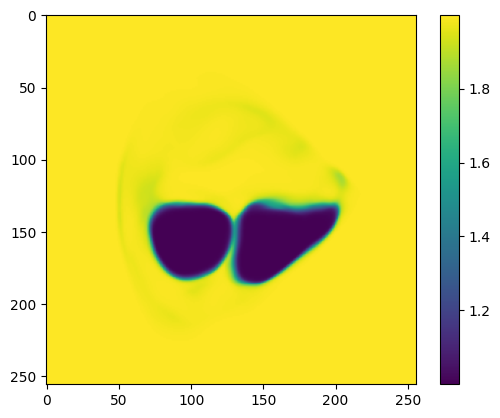

In [ ]:
x =pred_probs[0,0].clone()
print(x.max())
for i in range(pred_probs.shape[1]):
    x += pred_probs[0,i]
    print(x.max())
plt.imshow(x)
plt.colorbar()

plt.savefig('../test_img.png')